# Simulation of angular streaking with a realistic FEL

Here we simulate the effect of angular streaking in a FEL produced elsewhere.

We need to define a function E(t), which produces the FEL electric field for a given time point. If the FEL has been simulated in a separate tool and only a grid of time points for it is available (for instance: ocelot), one can create a function that interpolates the missing points.

This will be used here to produce more realistic FEL simulations for validation.


In [1]:
# this is needed to load the Julia interface internally
import envmodules
envmodules.load('exfel', 'julia')
import os
os.environ["JULIA_NUM_THREADS"] = 'auto'
os.environ['PYTHON_JULIAPKG_OFFLINE'] = 'no'


- EXFEL modulepath enabled


In [2]:
# from juliacall import Main as jl
# jl.seval("import Revise")

In [3]:
from quacksim import *

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Precompiling QuackSim...
  14405.3 ms  ✓ QuackSim
  1 dependency successfully precompiled in 18 seconds. 484 already precompiled.


[Wed, 10 Sep 2025 10:51:42] Loading file '/gpfs/exfel/data/scratch/danilo/envs/quack/lib/python3.10/site-packages/quacksim/src/../data/pcs_Kr1s.txt' with data for Kr4p_multi...
[Wed, 10 Sep 2025 10:51:43] Loading file '/gpfs/exfel/data/scratch/danilo/envs/quack/lib/python3.10/site-packages/quacksim/src/../data/pcs_Xe.txt' with data for Xe3d...
[Wed, 10 Sep 2025 10:51:43] Loading file '/gpfs/exfel/data/scratch/danilo/envs/quack/lib/python3.10/site-packages/quacksim/src/../data/pcs_Kr1s.txt' with data for Kr1s...
[Wed, 10 Sep 2025 10:51:43] Loading file '/gpfs/exfel/data/scratch/danilo/envs/quack/lib/python3.10/site-packages/quacksim/src/../data/pcs_Ne.txt' with data for Ne1s...
[Wed, 10 Sep 2025 10:51:43] Loading file '/gpfs/exfel/data/scratch/danilo/envs/quack/lib/python3.10/site-packages/quacksim/src/../data/pcs_N.txt' with data for N1s...
[Wed, 10 Sep 2025 10:51:43] Loading file '/gpfs/exfel/data/scratch/danilo/envs/quack/lib/python3.10/site-packages/quacksim/src/../data/pcs_Xe.txt' 

In [4]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Open file with E-field.

In [5]:
with h5py.File("../example/fel_nochirp.h5", "r") as fid:
    E_spec = fid["E_spec"][()]
    t_spec = fid["t_spec"][()]
    E_axis = fid["spec_E_axis"][()]
    t_axis = fid["spec_t_axis"][()]
    A_td = fid["time_domain_amplitude"][()]
    phi_td = fid["time_domain_phase"][()]
    t = fid["time_domain_axis"][()]
    wx = fid["E_photon"][()]/eV_per_au
    E = A_td*np.sin(wx*t + phi_td)
    E_photon = fid["E_photon"][()]


Text(0, 0.5, 'Intensity [a.u.]')

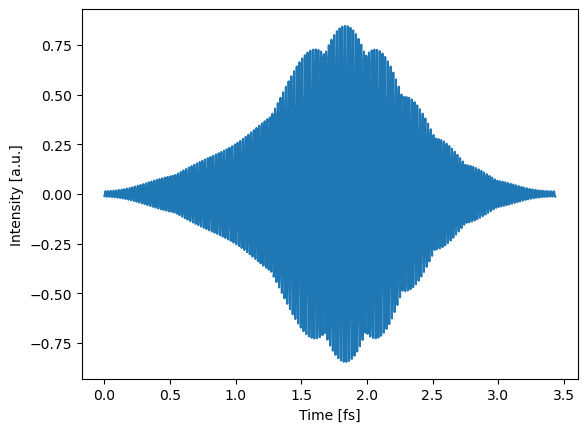

In [6]:
plt.plot(t*fs_per_au, E[0,:])
plt.xlabel("Time [fs]")
plt.ylabel("Intensity [a.u.]")

Text(0, 0.5, 'Intensity [a.u.]')

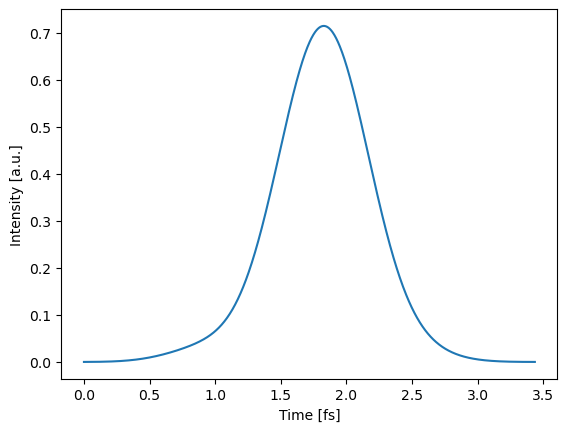

In [7]:
plt.plot(t_axis, t_spec[0,:])
plt.xlabel("Time [fs]")
plt.ylabel("Intensity [a.u.]")

(990.0, 1010.0)

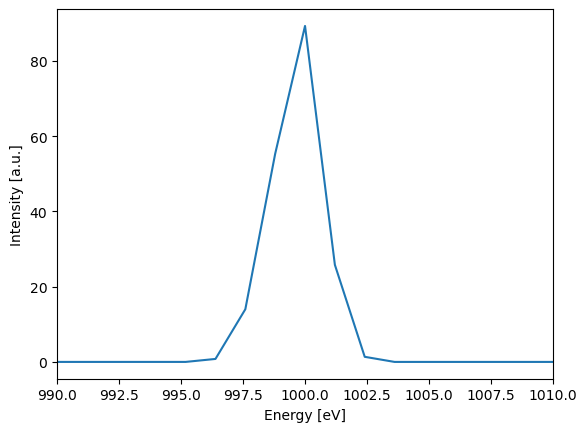

In [8]:
plt.plot(E_axis, E_spec[0,:])
plt.xlabel("Energy [eV]")
plt.ylabel("Intensity [a.u.]")
plt.xlim(1e3-10, 1e3+10)

In [9]:
# PES binding energy
gas = "Ne1s"
Ip = orbitals[gas]["Ip"]/eV_per_au

# laser settings
ll = 1030.0/nm_per_au
wl = 2*np.pi*c/ll
Tl = 2*np.pi/wl

# amplitude of the A-field for streaking: let's bump electrons with something like +/-10 eV
# units (it is defined here scaled by c): eV/e = Volt
# in atomic units: 1 a.u. of A = 27.2 V
Up = 0.2/eV_per_au
amp_Al = np.sqrt(4*Up)*c
# A = -c int_-inf^t E(t') dt'

# polarization
polarization = "horizontal"
beta = 2.0
tda = orbitals[gas]["tda_int"]

# create a grid for observations
W_axis = np.linspace(95.0/eV_per_au, 155.0/eV_per_au, 160)
theta_axis_deg = np.arange(0.0, 360.0, step=22.5)
theta_axis = theta_axis_deg*np.pi/180.0

NW, Ntheta = len(W_axis), len(theta_axis)

The laser period must match the time axis for the FEL field.

## Propagate

Check effect of two pulses getting close together, without streaking.

In [10]:
tspan=(0.0, Tl)

In [11]:
# create the object holding all information for the integration
result = []
ellipticity = 1.0
Nsim = E.shape[0]
for i in range(Nsim):
    # represent what we want to simulate
    p = create_custom_fel_from_svea(t, A_td[i], phi_td[i],            # time grid, time-dependent amplitude, time-dependent phase
                                    W_axis, theta_axis,               # observation Grid (eV, rad)
                                    E_photon/eV_per_au,               # FEL mean energy
                                    np.array([amp_Al]),               # streaking laser vector potential amplitude (V)
                                    wl,                               # streaking laser angular frequency
                                    Ip,                               # binding energy
                                    ellipticity,                      # ellipticity
                                    tda,
                                    False,
                                    beta,
                                    polarization
        )
    # returns an array of size: (NW, Nθ, NA) = (NW, Nθ, 1)
    # sum over all pairs of FEL times and energies
    B = calculate(p,
                  tspan,                 # time span
                  )    # slow, but careful integration
    # normalize
    B_cpu = B/np.sum(B)
    # take the only vector potential
    B_cpu = B_cpu[:,:,0]
    # store with an extra index, so we can concatenate over it later
    result += [B_cpu]
    

[Wed, 10 Sep 2025 10:51:55] Using analytical result for ϕ(t=Tl)...
[Wed, 10 Sep 2025 10:51:59] Calculating b(t=Tl)...
[Wed, 10 Sep 2025 10:52:23] Calculating observation...
[Wed, 10 Sep 2025 10:52:24] Using analytical result for ϕ(t=Tl)...
[Wed, 10 Sep 2025 10:52:24] Calculating b(t=Tl)...
[Wed, 10 Sep 2025 10:52:32] Calculating observation...
[Wed, 10 Sep 2025 10:52:32] Using analytical result for ϕ(t=Tl)...
[Wed, 10 Sep 2025 10:52:32] Calculating b(t=Tl)...
[Wed, 10 Sep 2025 10:52:39] Calculating observation...
[Wed, 10 Sep 2025 10:52:39] Using analytical result for ϕ(t=Tl)...
[Wed, 10 Sep 2025 10:52:39] Calculating b(t=Tl)...
[Wed, 10 Sep 2025 10:52:47] Calculating observation...
[Wed, 10 Sep 2025 10:52:47] Using analytical result for ϕ(t=Tl)...
[Wed, 10 Sep 2025 10:52:47] Calculating b(t=Tl)...
[Wed, 10 Sep 2025 10:52:56] Calculating observation...
[Wed, 10 Sep 2025 10:52:56] Using analytical result for ϕ(t=Tl)...
[Wed, 10 Sep 2025 10:52:56] Calculating b(t=Tl)...
[Wed, 10 Sep 2025

In [12]:
result = np.stack(result, axis=0);

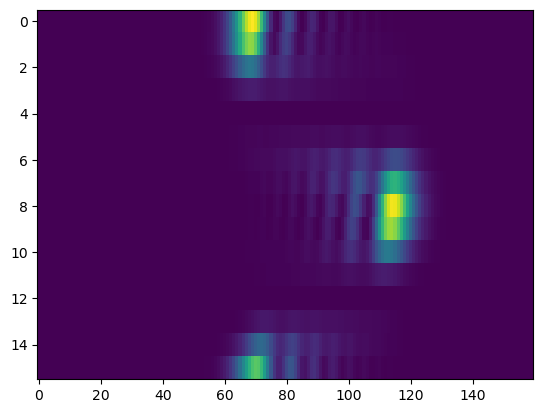

In [14]:
plt.imshow(result[0,...].T, aspect="auto")